In [1]:
# ==========================================
# Modelo Supervisado con KNN
# Dataset: Ejercicio Grupal Clase booking.csv
# Objetivo: Predecir si una reserva será cancelada o no
# ==========================================

# 1. Importar librerías
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [2]:
# 2. Cargar los datos
data = pd.read_csv("booking.csv")

print("Primeras filas del dataset:")
print(data.head())

Primeras filas del dataset:
  Booking_ID  number of adults  number of children  number of weekend nights  \
0   INN00001                 1                   1                         2   
1   INN00002                 1                   0                         1   
2   INN00003                 2                   1                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   

   number of week nights  type of meal  car parking space    room type  \
0                      5   Meal Plan 1                  0  Room_Type 1   
1                      3  Not Selected                  0  Room_Type 1   
2                      3   Meal Plan 1                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   

   lead time market segment type  repeated  P-

In [13]:
# 3. Explorar información básica
print("\nTamaño del dataset:")
print(data.shape)

print("\nColumnas:")
print(data.columns)

print("\nValores de la variable objetivo:")
print(data["booking status"].value_counts())


Tamaño del dataset:
(36285, 17)

Columnas:
Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'market segment type',
       'repeated', 'P-C', 'P-not-C', 'average price', 'special requests',
       'date of reservation', 'booking status'],
      dtype='object')

Valores de la variable objetivo:
booking status
Not_Canceled    24396
Canceled        11889
Name: count, dtype: int64


In [14]:
# 4. Definir X e y
# X = variables predictoras
# y = variable objetivo

X = data.drop(columns=["Booking_ID", "booking status", "date of reservation"])
y = data["booking status"]

In [15]:
# 5. Identificar variables numéricas y categóricas
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("\nVariables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)


Variables numéricas:
Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'car parking space', 'lead time', 'repeated',
       'P-C', 'P-not-C', 'average price', 'special requests'],
      dtype='object')

Variables categóricas:
Index(['type of meal', 'room type', 'market segment type'], dtype='object')


In [16]:
# 6. Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
#preprocessor = None # Eliminamos el ColumnTransformer, ya no lo usaremos en este paso

# 7. Preparar los datos manualmente
# Escalar las variables numéricas y codificar las categóricas

# Inicializamos el StandardScaler para las variables numéricas
scaler = StandardScaler()

# Inicializamos el OneHotEncoder para las variables categóricas
# handle_unknown='ignore' para evitar errores si aparece una categoría nueva en el conjunto de prueba
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Escalamos los datos numéricos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train[numeric_features])

# Transformar las variables numéricas del conjunto de prueba usando el escalador ajustado en el entrenamiento
X_test_scaled = scaler.transform(X_test[numeric_features])

# Ajustar y transformar las variables categóricas del conjunto de entrenamiento
# Codificamos los datos categóricos de entrenamiento
X_train_ohe = ohe.fit_transform(X_train[categorical_features])
# Obtener los nombres de las nuevas columnas creadas por OneHotEncoder

feature_names = ohe.get_feature_names_out(categorical_features)
# Transformar las variables categóricas del conjunto de prueba usando el codificador ajustado en el entrenamiento
X_test_ohe = ohe.transform(X_test[categorical_features])

# Convertir los arrays transformados a DataFrames para poder concatenarlos
# Creamos DataFrames a partir de los arrays escalados y codificados
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_features, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numeric_features, index=X_test.index)

X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=feature_names, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=feature_names, index=X_test.index)

# Concatenar las características numéricas escaladas y las categóricas codificadas
# Unimos las características procesadas para el conjunto de entrenamiento
X_train_processed = pd.concat([X_train_scaled_df, X_train_ohe_df], axis=1)
# Unimos las características procesadas para el conjunto de prueba
X_test_processed = pd.concat([X_test_scaled_df, X_test_ohe_df], axis=1)

In [18]:
# 8. Crear el modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

In [19]:
# 9. Entrenar el modelo y hacer predicciones
# Entrenar el modelo con los datos preprocesados de entrenamiento
model.fit(X_train_processed, y_train)

# Hacer predicciones en el conjunto de prueba preprocesado
y_pred = model.predict(X_test_processed)



In [20]:
# 10. Evaluar el modelo
# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)

print("\nPrecisión del modelo:")
print(accuracy)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Precisión del modelo:
0.857792476229847

Reporte de clasificación:
              precision    recall  f1-score   support

    Canceled       0.80      0.76      0.78      2378
Not_Canceled       0.88      0.91      0.90      4879

    accuracy                           0.86      7257
   macro avg       0.84      0.83      0.84      7257
weighted avg       0.86      0.86      0.86      7257



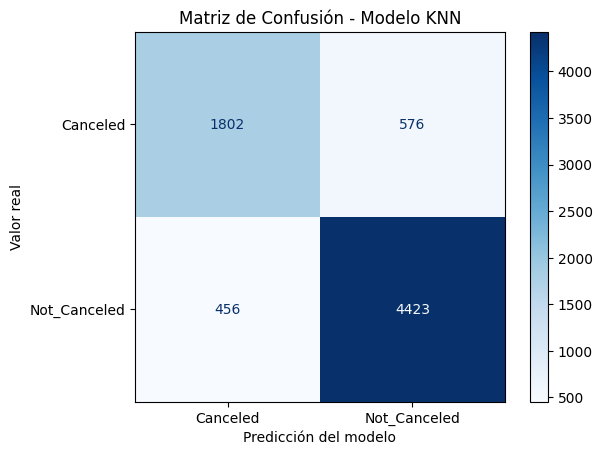

In [21]:
# 11. Visualizar la matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de Confusión - Modelo KNN")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.show()

In [25]:
# 12. Hacer una predicción con un nuevo caso
nuevo_cliente = X_test.iloc[[5]]

# Preprocesar el nuevo_cliente de la misma manera que se hizo con X_train y X_test
# Escalar las variables numéricas del nuevo cliente
nuevo_cliente_scaled = scaler.transform(nuevo_cliente[numeric_features])
nuevo_cliente_scaled_df = pd.DataFrame(nuevo_cliente_scaled, columns=numeric_features, index=nuevo_cliente.index)

# Codificar las variables categóricas del nuevo cliente
nuevo_cliente_ohe = ohe.transform(nuevo_cliente[categorical_features])
nuevo_cliente_ohe_df = pd.DataFrame(nuevo_cliente_ohe, columns=feature_names, index=nuevo_cliente.index)

# Concatenar las características preprocesadas del nuevo cliente
nuevo_cliente_processed = pd.concat([nuevo_cliente_scaled_df, nuevo_cliente_ohe_df], axis=1)

# Hacer la predicción con el modelo directamente
prediccion = model.predict(nuevo_cliente_processed)

print("\nPredicción para una nueva reserva:")
print(prediccion[0])


Predicción para una nueva reserva:
Canceled


In [24]:
nuevo_cliente

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests
26192,1,0,2,4,Meal Plan 1,0,Room_Type 1,245,Offline,0,0,0,110.0,0


In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# Obtener los valores de la primera fila del conjunto de prueba para usar como defecto
default_row_values = X_test.iloc[0]

# Obtener los valores únicos para las características categóricas, si no están ya disponibles
# Asegurarse de que 'data' esté disponible o cargarla si es necesario para obtener los valores únicos
if 'data' not in locals():
    data = pd.read_csv("booking.csv") # Recargar si no está en el scope
unique_categorical_values = {}
for col in categorical_features:
    unique_categorical_values[col] = data[col].unique().tolist()

# Crear widgets de entrada para cada característica
input_widgets = {}
for feature in numeric_features:
    input_widgets[feature] = widgets.FloatText(
        description=feature.replace('_', ' ').title() + ':',
        value=default_row_values[feature],
        continuous_update=False,
        layout=widgets.Layout(width='auto', font_size='16px'), # Ajustar tamaño de fuente para leer
        style={'description_width': 'initial'}
    )

for feature in categorical_features:
    input_widgets[feature] = widgets.Dropdown(
        description=feature.replace('_', ' ').title() + ':',
        options=unique_categorical_values[feature],
        value=default_row_values[feature],
        layout=widgets.Layout(width='auto', font_size='16px'), # Ajustar tamaño de fuente para leer
        style={'description_width': 'initial'}
    )

# Botón para hacer la predicción
predict_button = widgets.Button(
    description="Predecir",
    layout=widgets.Layout(width='auto', font_size='18px')
)
output_area = widgets.Output()

def make_prediction(b):
    with output_area:
        clear_output()
        # Recopilar los valores de los widgets
        new_data = {feature: [widget.value] for feature, widget in input_widgets.items()}
        nuevo_cliente_df = pd.DataFrame(new_data)

        # Asegurarse de que el orden de las columnas sea el mismo que en X
        nuevo_cliente_df = nuevo_cliente_df[numeric_features.tolist() + categorical_features.tolist()]

        # Preprocesar el nuevo_cliente de la misma manera que se hizo con X_train y X_test
        # Escalar las variables numéricas del nuevo cliente
        nuevo_cliente_scaled = scaler.transform(nuevo_cliente_df[numeric_features])
        nuevo_cliente_scaled_df = pd.DataFrame(nuevo_cliente_scaled, columns=numeric_features, index=nuevo_cliente_df.index)

        # Codificar las variables categóricas del nuevo cliente
        nuevo_cliente_ohe = ohe.transform(nuevo_cliente_df[categorical_features])
        nuevo_cliente_ohe_df = pd.DataFrame(nuevo_cliente_ohe, columns=feature_names, index=nuevo_cliente_df.index)

        # Concatenar las características preprocesadas del nuevo cliente
        nuevo_cliente_processed = pd.concat([nuevo_cliente_scaled_df, nuevo_cliente_ohe_df], axis=1)

        # Hacer la predicción con el modelo directamente
        prediccion = model.predict(nuevo_cliente_processed)

        print("\n--- Resultado de la Predicción ---")
        print(f"El estado de la reserva predicho es: {prediccion[0]}")

# Vincular el botón a la función de predicción
predict_button.on_click(make_prediction)

# Mostrar la interfaz
print("\nIntroduce los detalles de la nueva reserva para predecir su estado:")
display(widgets.VBox(list(input_widgets.values()) + [predict_button, output_area]))


Introduce los detalles de la nueva reserva para predecir su estado:
